In [1]:
# Import standard EDA and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visualization
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset (Make sure the file is in the same directory as your notebook)
file_path = "brick_400_samples_generated.xlsx"
df = pd.read_excel(file_path)

# Drop any empty 'Unnamed' columns that got carried over from Excel
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Display the first 5 rows to verify
display(df.head())

,Soil,Fly Ash,Coal Ash,Cow Dunk Ash,3-Day MPa,7-Day MPa,Water Absorption (%)
0,60,24,6,10,7.03,11.01,18.45
1,60,12,28,0,6.42,10.40,19.84
2,60,11,27,2,6.61,10.33,20.12
3,60,33,5,2,7.20,11.32,16.96
4,60,0,40,0,6.31,9.65,20.62


In [3]:
df.head()

,Soil,Fly Ash,Coal Ash,Cow Dunk Ash,3-Day MPa,7-Day MPa,Water Absorption (%)
0,60,24,6,10,7.03,11.01,18.45
1,60,12,28,0,6.42,10.40,19.84
2,60,11,27,2,6.61,10.33,20.12
3,60,33,5,2,7.20,11.32,16.96
4,60,0,40,0,6.31,9.65,20.62


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Soil                  400 non-null    int64  
 1   Fly Ash               400 non-null    int64  
 2   Coal Ash              400 non-null    int64  
 3   Cow Dunk Ash          400 non-null    int64  
 4   3-Day MPa             400 non-null    float64
 5   7-Day MPa             400 non-null    float64
 6   Water Absorption (%)  400 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 22.0 KB


In [5]:
df.shape

(400, 7)

In [6]:
df.columns

Index(['Soil', 'Fly Ash', 'Coal Ash', 'Cow Dunk Ash', '3-Day MPa', '7-Day MPa',
       'Water Absorption (%)'],
      dtype='str')

In [7]:
df.describe()

,Soil,Fly Ash,Coal Ash,Cow Dunk Ash,3-Day MPa,7-Day MPa,Water Absorption (%)
count,400.0,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,60.0,21.620000,10.975000,7.405000,6.823925,10.729400,19.337075
std,0.0,10.536991,11.311465,9.567645,0.363226,0.569615,1.594621
min,60.0,0.000000,0.000000,0.000000,5.700000,9.020000,16.870000
25%,60.0,14.000000,0.000000,0.000000,6.590000,10.290000,18.127500
50%,60.0,22.000000,8.000000,2.000000,6.895000,10.830000,18.825000
75%,60.0,30.250000,16.000000,11.250000,7.090000,11.160000,20.335000
max,60.0,40.000000,40.000000,40.000000,7.510000,11.920000,24.310000


In [8]:
df.isnull().sum()

Soil                    0
Fly Ash                 0
Coal Ash                0
Cow Dunk Ash            0
3-Day MPa               0
7-Day MPa               0
Water Absorption (%)    0
dtype: int64

In [9]:
corr = df.corr(numeric_only=True)
corr

,Soil,Fly Ash,Coal Ash,Cow Dunk Ash,3-Day MPa,7-Day MPa,Water Absorption (%)
Soil,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fly Ash,NaN,1.000000,-0.618504,-0.370081,0.870519,0.901583,-0.811953
Coal Ash,NaN,-0.618504,1.000000,-0.501094,-0.378555,-0.413791,0.175773
Cow Dunk Ash,NaN,-0.370081,-0.501094,1.000000,-0.511164,-0.503718,0.686406
3-Day MPa,NaN,0.870519,-0.378555,-0.511164,1.000000,0.869701,-0.881199
7-Day MPa,NaN,0.901583,-0.413791,-0.503718,0.869701,1.000000,-0.871907
Water Absorption (%),NaN,-0.811953,0.175773,0.686406,-0.881199,-0.871907,1.000000


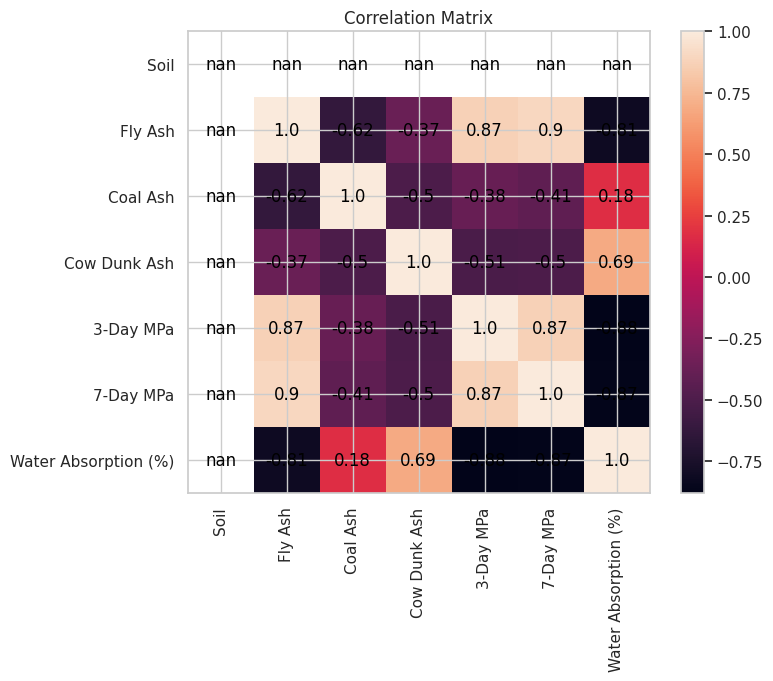

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# 👇 add values inside each box
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center', color='black')

plt.title("Correlation Matrix")
plt.show()

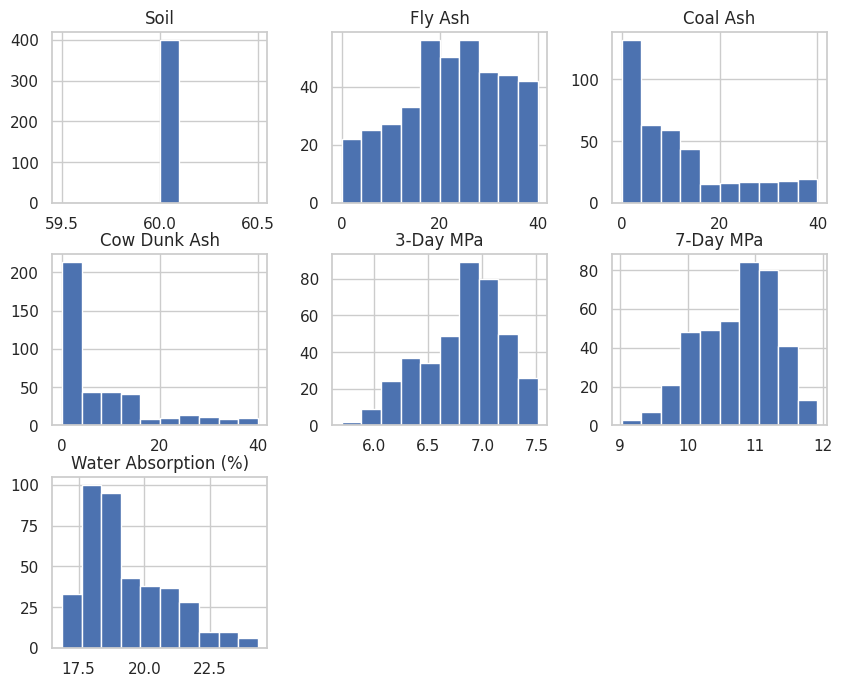

In [11]:
df.hist(figsize=(10,8))
plt.show()

In [12]:
df.columns

Index(['Soil', 'Fly Ash', 'Coal Ash', 'Cow Dunk Ash', '3-Day MPa', '7-Day MPa',
       'Water Absorption (%)'],
      dtype='str')

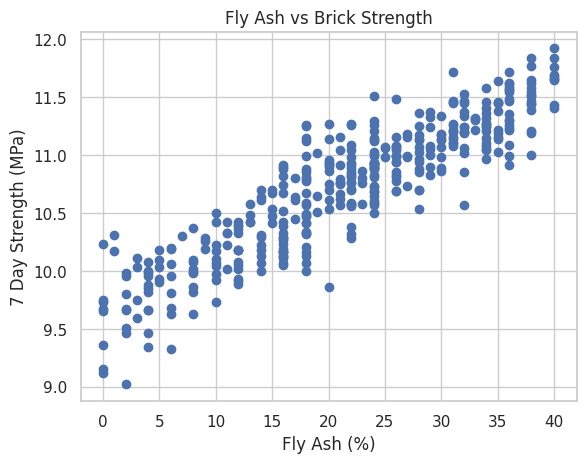

In [13]:
plt.scatter(df['Fly Ash'], df['7-Day MPa'])

plt.xlabel("Fly Ash (%)")
plt.ylabel("7 Day Strength (MPa)")
plt.title("Fly Ash vs Brick Strength")

plt.show()

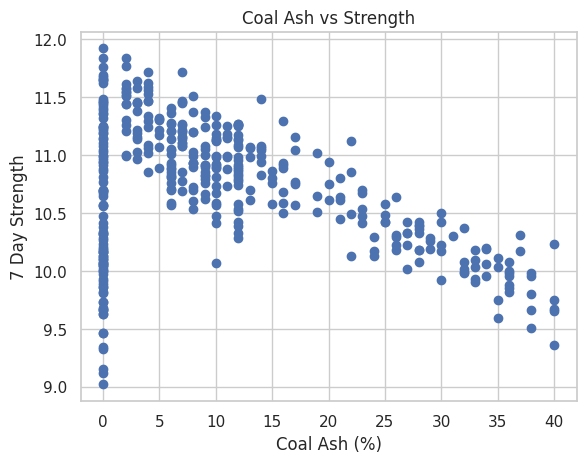

In [14]:
plt.scatter(df['Coal Ash'], df['7-Day MPa'])

plt.xlabel("Coal Ash (%)")
plt.ylabel("7 Day Strength")

plt.title("Coal Ash vs Strength")

plt.show()

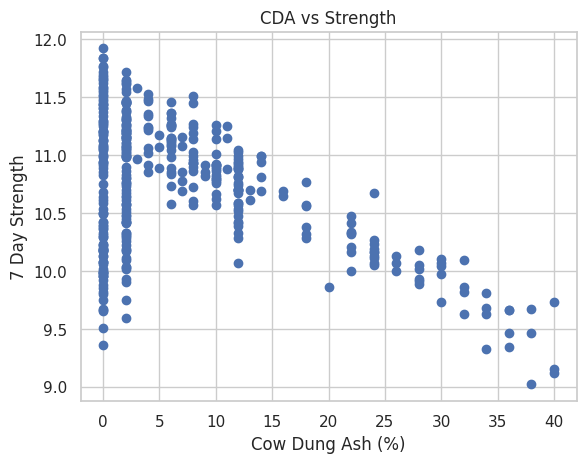

In [15]:
plt.scatter(df['Cow Dunk Ash'], df['7-Day MPa'])

plt.xlabel("Cow Dung Ash (%)")
plt.ylabel("7 Day Strength")

plt.title("CDA vs Strength")

plt.show()

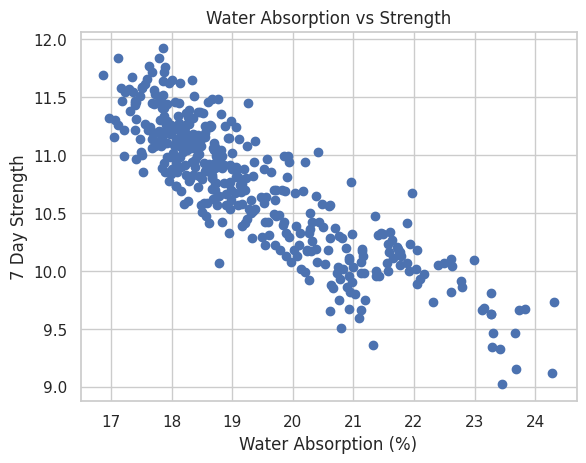

In [16]:
plt.scatter(df['Water Absorption (%)'], df['7-Day MPa'])

plt.xlabel("Water Absorption (%)")
plt.ylabel("7 Day Strength")

plt.title("Water Absorption vs Strength")

plt.show()

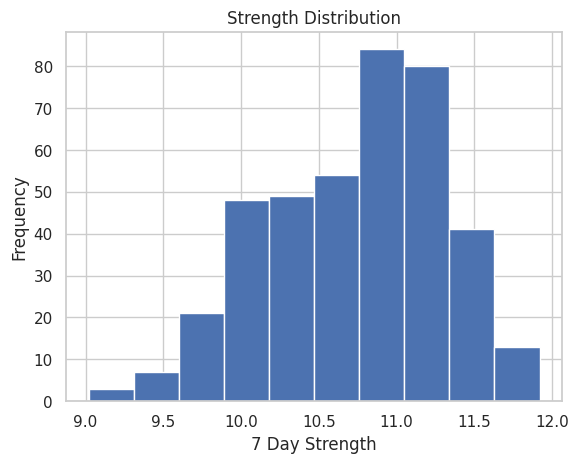

In [17]:
plt.hist(df['7-Day MPa'], bins=10)

plt.xlabel("7 Day Strength")
plt.ylabel("Frequency")

plt.title("Strength Distribution")

plt.show()

In [18]:
df.to_csv("clean_brick_data.csv", index=False)

In [19]:
df.columns

Index(['Soil', 'Fly Ash', 'Coal Ash', 'Cow Dunk Ash', '3-Day MPa', '7-Day MPa',
       'Water Absorption (%)'],
      dtype='str')

In [20]:
X = df[['Soil',
        'Fly Ash',
        'Coal Ash',
        'Cow Dunk Ash',
        'Water Absorption (%)']]

In [21]:
y = df[['3-Day MPa','7-Day MPa']]

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [24]:
    # Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
X_train

,Soil,Fly Ash,Coal Ash,Cow Dunk Ash,Water Absorption (%)
3,60,33,5,2,16.96
18,60,16,0,24,21.77
202,60,10,30,0,19.55
250,60,6,0,34,23.27
274,60,38,0,2,18.34
...,...,...,...,...,...
71,60,24,8,8,18.44
106,60,16,0,24,21.76
270,60,16,0,24,21.74
348,60,24,10,6,17.85


In [26]:
X_test

,Soil,Fly Ash,Coal Ash,Cow Dunk Ash,Water Absorption (%)
209,60,16,12,12,19.00
280,60,28,0,12,19.93
33,60,20,12,8,18.48
210,60,10,0,30,22.17
93,60,16,12,12,18.94
...,...,...,...,...,...
246,60,34,0,6,18.60
227,60,28,12,0,18.97
369,60,26,7,7,18.09
176,60,38,2,0,17.86


In [27]:
y_train

,3-Day MPa,7-Day MPa
3,7.20,11.32
18,6.40,10.05
202,6.55,10.22
250,6.15,9.81
274,7.42,11.65
...,...,...
71,6.88,10.72
106,6.24,10.16
270,6.63,10.19
348,6.99,10.89


In [28]:
y_test

,3-Day MPa,7-Day MPa
209,6.79,10.88
280,6.86,10.94
33,6.91,11.14
210,6.04,9.97
93,6.92,10.33
...,...,...
246,7.04,11.46
227,7.20,10.53
369,6.83,10.85
176,7.41,11.52


In [29]:
# Model (Multi-output Random Forest)
model = MultiOutputRegressor(RandomForestRegressor(
    n_estimators=100,
    random_state=42
))

In [30]:
# Train
model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least

In [31]:
y_pred = model.predict(X_test)

In [32]:
# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 0.042810444476614466
R2 Score: 0.8055973299299719


In [35]:
import os

In [36]:
os.makedirs("model", exist_ok=True)

# Now save model
joblib.dump(model, "./model/brick_strength_model.pkl")

['./model/brick_strength_model.pkl']

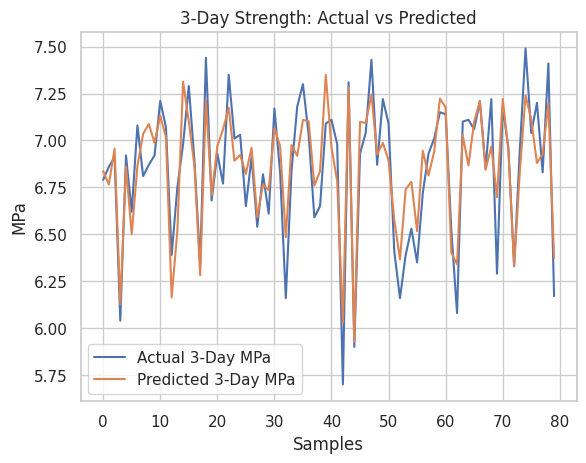

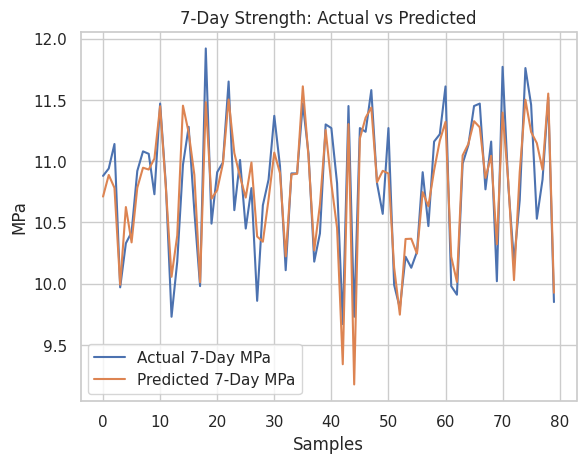

In [38]:
y_pred = model.predict(X_test)

x_axis = range(len(y_test))

# 🔷 3-Day MPa Line Plot
plt.figure()
plt.plot(x_axis, y_test.iloc[:, 0], label="Actual 3-Day MPa")
plt.plot(x_axis, y_pred[:, 0], label="Predicted 3-Day MPa")

plt.xlabel("Samples")
plt.ylabel("MPa")
plt.title("3-Day Strength: Actual vs Predicted")
plt.legend()
plt.show()


# 🔷 7-Day MPa Line Plot
plt.figure()
plt.plot(x_axis, y_test.iloc[:, 1], label="Actual 7-Day MPa")
plt.plot(x_axis, y_pred[:, 1], label="Predicted 7-Day MPa")

plt.xlabel("Samples")
plt.ylabel("MPa")
plt.title("7-Day Strength: Actual vs Predicted")
plt.legend()
plt.show()

In [39]:
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 80.56%
